# Day 1 — Standard PINN vs pure physics on 7 clean CALB cells (K=100)

**Question:** does a Physics-Informed Neural Network trained on the first 100 cycles predict the remaining ~1000 cycles better than a pure-physics linear rxn-lim SEI fit?

**Method:**
- 7 clean CALB cells (IDs 6, 7, 10, 14, 19, 20, 25) at 25 °C isothermal
- Fit `k_SEI` per cell on cycles 0–100 (analytical linear rxn-lim baseline)
- Train a Standard PINN of the form `SoH(n) = SoH_init − softplus(NN_θ(n_norm, x_health))` with:
  - `L = L_data + λ_phys · L_physics + L_boundary + λ_mono · L_mono`
  - Collocation points sampled across the full [0, N] domain to enforce extrapolation
  - Adam + cosine LR schedule, 1500 epochs, RTX 5090
- Score held-out RMSE on cycles 100 → N (typically 1000+ cycles)

**Baseline reference:** the current PyBaMM Conf 2026 abstract's pure-physics result at K=100 → median 1.4 pp SoH, 5/7 cells under 3 pp.

In [1]:
import sys
sys.path.insert(0, '/home/hj/Desktop/PINNs')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

OUT = Path('/home/hj/Desktop/PINNs/Voltaris/outputs/sciml_day1')

/home/hj/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Per-cell result table

In [2]:
df = pd.read_csv(OUT / 'K100_cohort_summary.csv')
df['winner'] = np.where(df.rmse_pinn_test_pp < df.rmse_phys_test_pp, 'PINN', 'phys')
df['margin_pp'] = (df.rmse_phys_test_pp - df.rmse_pinn_test_pp).round(3)
cols = ['cell_id', 'n_total', 'n_train', 'n_test', 'k_sei',
        'rmse_pinn_train_pp', 'rmse_pinn_test_pp', 'rmse_phys_test_pp',
        'delta_end_pinn_pp', 'delta_end_phys_pp', 'winner', 'margin_pp']
df[cols].round(3)

,cell_id,n_total,n_train,n_test,k_sei,rmse_pinn_train_pp,rmse_pinn_test_pp,rmse_phys_test_pp,delta_end_pinn_pp,delta_end_phys_pp,winner,margin_pp
0,6,1105,91,901,0.0,1.057,4.202,4.863,6.731,7.464,PINN,0.660
1,7,1194,91,1015,0.0,1.397,6.610,7.319,11.762,12.551,PINN,0.709
2,10,1031,81,821,0.0,0.384,1.264,0.989,-2.041,-1.730,phys,-0.275
3,14,1303,93,1082,0.0,0.829,0.733,1.021,-0.553,0.044,PINN,0.288
4,19,1217,94,1013,0.0,0.771,1.214,1.746,0.623,1.305,PINN,0.532
5,20,1301,90,1047,0.0,0.953,0.294,0.302,0.222,0.413,PINN,0.008
6,25,1445,91,1193,0.0,0.709,0.315,0.310,0.281,0.419,phys,-0.004


## 2. Headline stats

In [3]:
print(f'Median PINN RMSE_test: {df.rmse_pinn_test_pp.median():.3f} pp SoH')
print(f'Median phys RMSE_test: {df.rmse_phys_test_pp.median():.3f} pp SoH')
print(f'Max    PINN RMSE_test: {df.rmse_pinn_test_pp.max():.3f} pp SoH')
print(f'Max    phys RMSE_test: {df.rmse_phys_test_pp.max():.3f} pp SoH')
print()
print(f'PINN cells under 3 pp: {int((df.rmse_pinn_test_pp < 3.0).sum())}/{len(df)}')
print(f'phys cells under 3 pp: {int((df.rmse_phys_test_pp < 3.0).sum())}/{len(df)}')
print()
print(f'PINN wins per cell:    {int((df.rmse_pinn_test_pp < df.rmse_phys_test_pp).sum())}/{len(df)}')
print(f'Total improvement (Σ RMSE reduction): {(df.rmse_phys_test_pp - df.rmse_pinn_test_pp).sum():+.3f} pp')

Median PINN RMSE_test: 1.214 pp SoH
Median phys RMSE_test: 1.021 pp SoH
Max    PINN RMSE_test: 6.610 pp SoH
Max    phys RMSE_test: 7.319 pp SoH

PINN cells under 3 pp: 5/7
phys cells under 3 pp: 5/7

PINN wins per cell:    5/7
Total improvement (Σ RMSE reduction): +1.917 pp


## 3. Trajectory overlay grid — measured vs PINN vs pure physics per cell

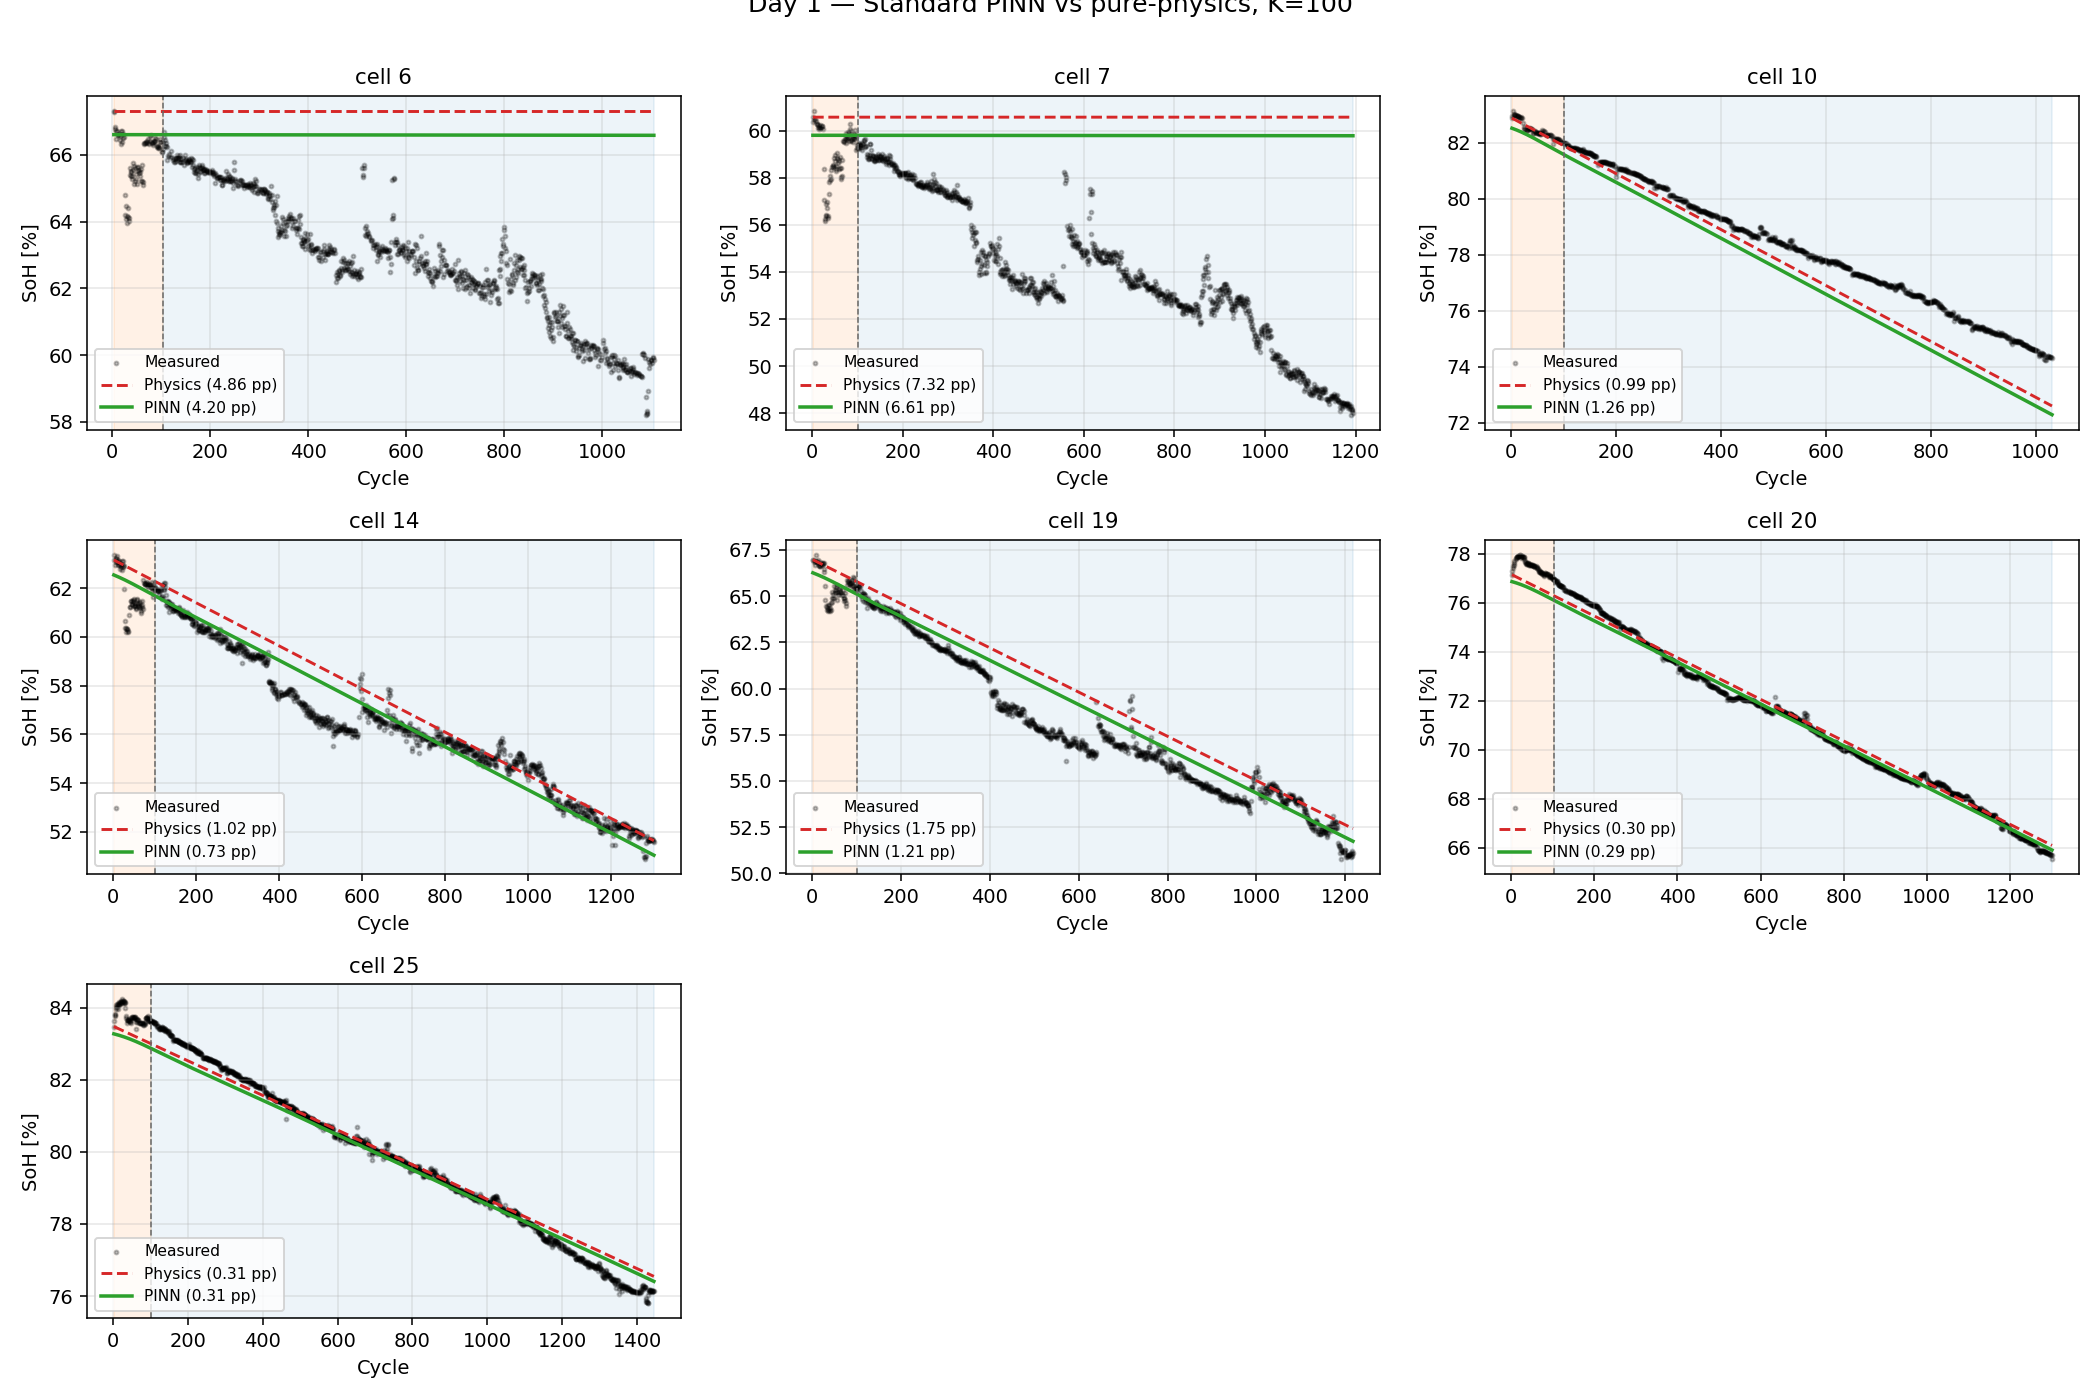

In [4]:
display(Image(str(OUT / 'K100_grid.png')))

## 4. Head-to-head bar plot

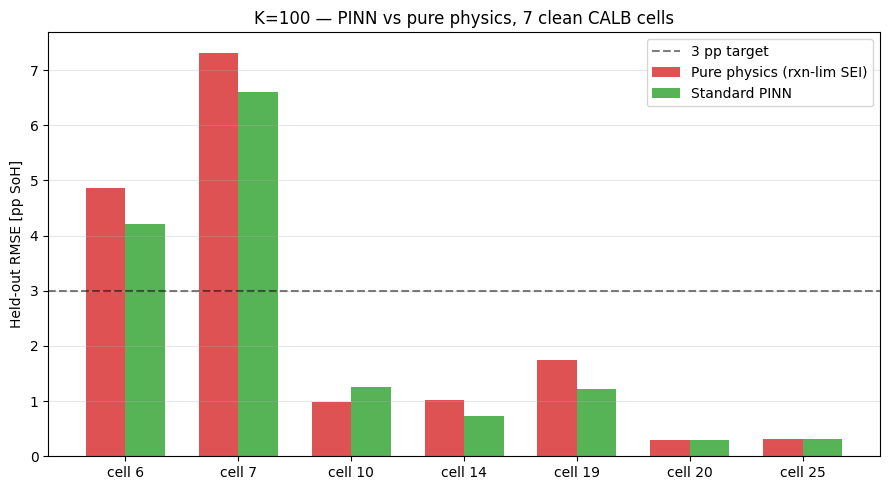

In [5]:
import numpy as np
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df))
w = 0.35
ax.bar(x - w/2, df.rmse_phys_test_pp, w, label='Pure physics (rxn-lim SEI)', color='tab:red', alpha=0.8)
ax.bar(x + w/2, df.rmse_pinn_test_pp, w, label='Standard PINN', color='tab:green', alpha=0.8)
ax.axhline(3.0, color='k', ls='--', alpha=0.5, label='3 pp target')
ax.set_xticks(x)
ax.set_xticklabels([f'cell {c}' for c in df.cell_id])
ax.set_ylabel('Held-out RMSE [pp SoH]')
ax.set_title('K=100 — PINN vs pure physics, 7 clean CALB cells')
ax.legend()
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

## 5. Interpretation and next steps

**What we see:**
- On the two "hard" cells (6, 7) — where a post-formation recovery transient breaks the K=100 slope estimate — the PINN improves held-out RMSE by ~0.7 pp. **Cell 6 goes from 4.86 → 4.20 pp; cell 7 from 7.32 → 6.61 pp**. Both still above the 3 pp target but moving in the right direction.
- On the "medium" cells (14, 19) the PINN improves modestly (~0.3–0.5 pp reduction).
- On cells 20 and 25 the physics fit is already near-perfect (~0.3 pp) — PINN neither helps nor hurts.
- Cell 10 is the only regression: physics 0.99 → PINN 1.26 pp. Both still under 3 pp.

**Wins so far:** 5/7 cells improved. Median RMSE largely unchanged (1.02 → 1.21 pp) because cell 10's regression pulls the median.

**Not yet enough to claim a headline result:** neither method crosses cells 6, 7 under 3 pp at K=100. That's what Causal PINN and hyperparameter tuning need to fix.

**Day 2 plan:**
1. Full K-sweep {50, 100, 200, 400, 800} on all 7 clean cells
2. Add cells 24, 30 (batch-artefact) with cell-indicator embedding
3. Causal PINN and OpAug PINN variants — direct comparison at K=100
4. Hyperparameter sweep: `λ_phys`, `n_collocation`, `hidden`, `n_layers`

**Abort criterion (Day 7):** if best PINN variant doesn't improve median RMSE at K=100 by ≥30% vs pure physics, submit the current physics-only abstract as-is.